# **Entendimiento de los Datos**
---

## **0. Integrantes del equipo de trabajo**
---

1. **Kevin Andres Leal Perez** (CC 1000519441)
2. **Dairo Enrique Morales Jimenez** (CC 1006656409)
3. **Sergio Andres Sierra Garcia** (CC 1010026343)

## **1. Carga de datos**
---

En esta fase se realiza la **carga y organización inicial** del dataset RealWaste desde MyNAS, preparando una estructura tabular con la ruta de cada imagen y su etiqueta. Esta decisión facilita el análisis posterior porque centraliza la información en un DataFrame, permitiendo cálculos de calidad, conteos y distribución de clases de forma directa.

- **Fuente de datos**: descarga automatizada con `dvc`.
- **Estructura esperada**: carpetas por clase dentro de `RealWaste`.
- **Salida clave**: tabla `df` con columnas `image_path` y `label`, base para todo el análisis exploratorio.

In [2]:
import os
import keras
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

In [ ]:
#!net use Z: "\\192.168.0.12\data-metodologias" /user:"usuario" "contraseña" /persistent:yes
!dvc pull -r mynas realwaste

In [ ]:
import pathlib

# Buscar la raíz del proyecto (contiene data.dvc) desde el directorio actual
_cwd = pathlib.Path().resolve()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents) if (p / "realwaste.dvc").exists()),
    _cwd
)
path = str(_root / "realwaste")

# Construir DataFrame con rutas y etiquetas
records = []
for label in sorted(os.listdir(path)):
    label_dir = os.path.join(path, label)
    if os.path.isdir(label_dir):
        for filename in sorted(os.listdir(label_dir)):
            if filename.lower().endswith(".jpg"):
                records.append({"image_path": os.path.join(label_dir, filename), "label": label})

df = pd.DataFrame(records)
print("Path to dataset files:", path)
print(f"Dataset cargado: {len(df)} imágenes")

Path to dataset files: C:\Users\sserg\Documents\Maestría Ing Sistemas\Proyecto AyV\Metodologias_Agiles_ML\data
Dataset cargado: 4752 imágenes


Por medio de la información de la organización de las carpetas podemos observar que existen 9 clases distintas de basura:

In [4]:
os.listdir(path)

['Cardboard',
 'Food Organics',
 'Glass',
 'Metal',
 'Miscellaneous Trash',
 'Paper',
 'Plastic',
 'Textile Trash',
 'Vegetation']

In [5]:
df.sample(3)

,image_path,label
228,C:\Users\sserg\Documents\Maestría Ing Sistemas...,Cardboard
2697,C:\Users\sserg\Documents\Maestría Ing Sistemas...,Paper
2859,C:\Users\sserg\Documents\Maestría Ing Sistemas...,Paper


Para continuar con el análisis se verifica la estructura del directorio para tener una visión que nos permita entender como se encuentran organizadas las imágenes

In [6]:
def print_directory_structure(folder_path, max=3):
  i = 0
  for root, dirs, files in os.walk(folder_path):
    level = root.replace(folder_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f'{indent}{os.path.basename(root)}/')

    subindent = ' ' * 4 * (level + 1)
    jpg_files = [f for f in files if f.lower().endswith('.jpg')]

    # Mostrar solo 3 archivos .jpg por carpeta
    for f in jpg_files[:3]:
      print(f'{subindent}{f}')

    i += 1
    if i == max:
      break

directory_to_explore = path

print(f"Estructura del directorio: {directory_to_explore}")
print_directory_structure(directory_to_explore,10)

Estructura del directorio: C:\Users\sserg\Documents\Maestría Ing Sistemas\Proyecto AyV\Metodologias_Agiles_ML\data
data/
    Cardboard/
        Cardboard_1.jpg
        Cardboard_10.jpg
        Cardboard_100.jpg
    Food Organics/
        Food Organics_1.jpg
        Food Organics_10.jpg
        Food Organics_100.jpg
    Glass/
        Glass_1.jpg
        Glass_10.jpg
        Glass_100.jpg
    Metal/
        Metal_1.jpg
        Metal_10.jpg
        Metal_100.jpg
    Miscellaneous Trash/
        Miscellaneous Trash_1.jpg
        Miscellaneous Trash_10.jpg
        Miscellaneous Trash_100.jpg
    Paper/
        Paper_1.jpg
        Paper_10.jpg
        Paper_100.jpg
    Plastic/
        Plastic_1.jpg
        Plastic_10.jpg
        Plastic_100.jpg
    Textile Trash/
        Textile Trash_1.jpg
        Textile Trash_10.jpg
        Textile Trash_100.jpg
    Vegetation/
        Vegetation_1.jpg
        Vegetation_10.jpg
        Vegetation_100.jpg


La exploración de carpetas confirma que el dataset está organizado por **categorías semánticas**, un requisito importante para problemas de clasificación supervisada. Además, imprimir ejemplos de archivos por directorio ayuda a validar rápidamente que las etiquetas están representadas y que la ruta de trabajo apunta al lugar correcto.

## **2. Análisis Exploratorio de los Datos**
---

### **2.1. Resumen General**
---

- ¿Cuántas imágenes tiene el dataset?
- ¿En qué formato están guardados los datos?
- ¿Qué tamaño en MB tiene el conjunto?

In [7]:
# Número de imágenes
num_images = len(df)
print(f"Número total de imágenes: {num_images}")

Número total de imágenes: 4752


El conteo total de registros permite dimensionar el problema y estimar la **capacidad computacional** necesaria para entrenamiento, validación y pruebas. Este indicador también sirve como línea base para comparar cambios posteriores, por ejemplo, después de limpieza o aumento de datos. Con esto sabemos que el número total de imágenes es 4752.

In [8]:
# Formato de las imágenes
def get_file_formats(folder_path):
    file_formats = set()

    for root, _, files in os.walk(folder_path):
        for filename in files:
            file_extension = os.path.splitext(filename)[1].lower()
            file_formats.add(file_extension)

    return file_formats

def get_image_size(folder_path):
    sizes = set()
    for root, _, files in os.walk(folder_path):
        for filename in files:
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                  img_array = np.array(img)
                  sizes.add(img_array.shape)
            except UnidentifiedImageError:
                print(f"Archivo no reconocido como imagen: {file_path}")
    return sizes

file_formats = get_file_formats(path)
print(f"Formatos de archivo en la carpeta de imágenes: {', '.join(file_formats)}")
image_sizes = get_image_size(path)
print(f"Tamaños de imágenes: {', '.join([str(size) for size in image_sizes])}")

Formatos de archivo en la carpeta de imágenes: .jpg
Tamaños de imágenes: (524, 524, 3)


La revisión de **formatos de archivo** y **resoluciones** es esencial para anticipar transformaciones de preprocesamiento. Si existen múltiples tamaños o formatos, el modelo requerirá normalización explícita (redimensionamiento y estandarización) para evitar sesgos técnicos durante el entrenamiento.

Este paso también cumple una función de control de calidad: identificar archivos no reconocidos y heterogeneidad extrema en dimensiones permite decidir estrategias robustas de lectura y limpieza antes de construir lotes de datos.

Con la anterior salida podemos evidenciar que el conjunto de datos está muy bien organizado, pues todas las imágenes presentan el mismo formato `.jpg` y las mismas dimensiones (524 x 524), además observamos que todas son imágenes a color, por lo cual existen los 3 canales de colores.

In [9]:
def get_size(folder_path):
    total_size = sum(
        os.path.getsize(os.path.join(root, filename))
        for root, _, files in os.walk(folder_path)
        for filename in files
    )

    return total_size

total_size = get_size(path) / (1024 ** 2)

print(f"Tamaño del conjunto de datos: {total_size:.2f} MB")

Tamaño del conjunto de datos: 656.42 MB


El tamaño total del dataset en MB aporta una medida directa del **costo de almacenamiento y transferencia**. Considerando que el peso del conjunto de datos es de apenas 656.42 MB, este es un valor pequeño que permite un manejo sencillo de la información y que también nos permitirá utilizar técnicas de Data Augmentation sin preocuparnos por exceder las capacidades de procesamiento local.

### **2.2. Resumen de la Calidad de los datos**
---

- ¿Hay datos faltantes o imágenes vacías?
- ¿Existen imágenes ilegibles o con problemas de codificación?

El análisis de valores faltantes muestra la completitud de los metadatos mínimos (`image_path`, `label`), condición necesaria para mantener la integridad del pipeline. En datasets de imágenes, esta verificación evita fallos silenciosos al momento de indexar archivos o asignar etiquetas durante el entrenamiento.

- **Objetivo**: confirmar que no existan filas incompletas en el DataFrame.
- **Riesgo mitigado**: errores en la lectura de imágenes y desalineación entre entrada y clase objetivo.

In [10]:
# Valores faltantes por columna
missing_counts = df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_counts)
print(df.label.unique())

Valores faltantes por columna:
image_path    0
label         0
dtype: int64
['Cardboard' 'Food Organics' 'Glass' 'Metal' 'Miscellaneous Trash' 'Paper'
 'Plastic' 'Textile Trash' 'Vegetation']


En este caso, se observa que no hay problemas presentes en el etiquetado de las imágenes y todas cuentan con un valor de las 9 clases disponibles.

In [11]:
def check_image_files(folder_path):
    errors = []
    dirs = list(os.walk(folder_path))[1:]  # Omitir el directorio raíz

    for i, register in enumerate(dirs):
        root, _, files = register
        print(f'\r Analizados {i+1} de {len(dirs)} etiquetas de basura',end='')
        for filename in files:
            file_path = os.path.join(root, filename)
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    img = Image.open(file_path)
                    img_array = np.array(img)

                if img_array.size == 0:
                    errors.append((file_path, "Imagen vacía"))

                elif np.all(img_array == img_array.flat[0]):
                    errors.append((file_path, "Imagen constante"))

            except UnidentifiedImageError:
                errors.append((file_path, "No se puede leer la imagen (formato no reconocido)"))

            except Exception as e:
                errors.append((file_path, f"Error: {e}"))
    return errors


image_errors = check_image_files(path)

print(f"\n Problemas en los archivos de imagen: {len(image_errors)}")

if image_errors:
    for path, reason in image_errors:
        print(f"   - {reason} → {path}")

 Analizados 9 de 9 etiquetas de basura
 Problemas en los archivos de imagen: 0


La rutina de validación de imágenes profundiza la calidad del conjunto al detectar archivos **ilegibles**, imágenes vacías o con contenido constante. Este control es clave porque problemas de codificación o corrupción pueden degradar el aprendizaje y aumentar ruido en las métricas del modelo. Para este caso, encontramos que no hay imágenes irreconocibles para el proyecto.

### **2.3. Tipos de variables**
---

- ¿El conjunto de datos tiene una variable objetivo a estimar?, de ser así, ¿es una variable continúa o categórica?
- Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.

In [12]:
# Variable objetivo y tipo
variable_objetivo = 'label'
print(f"Variable objetivo: {variable_objetivo}")
print(f"Tipo de variable objetivo: {'Categórica' if df[variable_objetivo].dtype == 'object' else 'Continua'}")
# Número de categorías de la variable objetivo
categorias = df[variable_objetivo].unique()
print(f"Número de categorías de la variable objetivo: {len(categorias)}")

Variable objetivo: label
Tipo de variable objetivo: Categórica
Número de categorías de la variable objetivo: 9


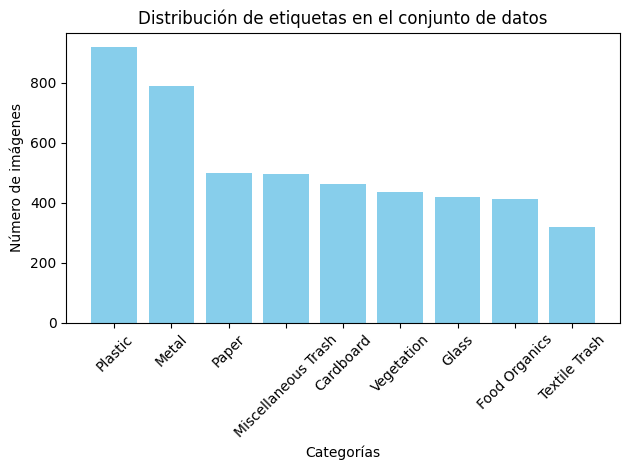

,image_path
label,
Plastic,921
Metal,790
Paper,500
Miscellaneous Trash,495
Cardboard,461
Vegetation,436
Glass,420
Food Organics,411
Textile Trash,318


In [13]:
# Distribución de etiquetas
conteos = df.groupby(variable_objetivo).agg({'image_path': 'size'}).sort_values(by='image_path', ascending=False)

plt.bar(conteos.index, conteos['image_path'], color='skyblue')
plt.xlabel('Categorías')
plt.ylabel('Número de imágenes')
plt.title('Distribución de etiquetas en el conjunto de datos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

conteos.style.background_gradient(cmap='Blues').set_caption("Distribución de etiquetas en el conjunto de datos")

La variable objetivo identificada es **categórica** (`label`), por lo que el problema corresponde a clasificación multiclase. El gráfico de frecuencias y la tabla de conteos permiten evaluar el **desbalance de clases**, aspecto crítico porque puede sesgar el modelo hacia categorías mayoritarias.

Con base en el gráfico y tablas presentados se identifica que las categorías con mayor cantidad de imágenes por analizar son plasticos y metales, mientras que la de menor frecuencia es la basura textil.

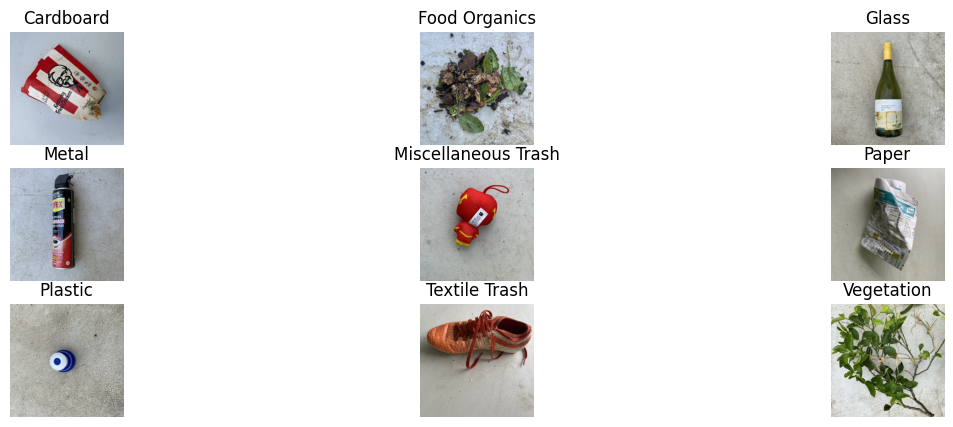

In [14]:
# Representación de imagen aleatoria por categoría
fig, axes = plt.subplots(3, 3, figsize=(15, 5))
for i, category in enumerate(categorias):
    category_images = df[df[variable_objetivo] == category]['image_path']
    random_image_path = np.random.choice(category_images)
    img = Image.open(random_image_path)
    axes[i // 3, i % 3].imshow(img)
    axes[i // 3, i % 3].set_title(category)
    axes[i // 3, i % 3].axis('off')

Por medio de la anterior visualización podemos representar de forma aleatoria una imagen de cada tipo de residuo. Desde este punto se evidencia que los residuos presentes en cada clase pueden estar ubicados sobre distintas superficies con colores similares, también que la cantidad de luz puede ser algo variable, y en general todas las fotos parecen tomadas desde un mismo ángulo superior al objeto ubicado sobre la superficie. El tamaño de los residuos es bastante variable no solo entre categorías sino también dentro de las categorías.

Todos estas características sobre las imágenes son de esperarse al considerar que el conjunto de datos fue recolectado con el propósito de que se asemejara lo mejor posible a las condiciones reales de donde se encuentran los residuos en los distintos vertederos.

# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](https://www.linkedin.com/in/mario-andres-rodriguez-triana-394806145/).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*